## Load the data

In [1]:
from pathlib import Path
import pandas as pd

PROJECT = Path.home() / "Projects/xenium_lung"

VIS_DIR = PROJECT / "results/xenium_5k/visualization"

coordinates = pd.read_parquet(
    VIS_DIR / "cell_coordinates.parquet"
)

clusters = pd.read_csv(
    VIS_DIR / "cluster_labels.csv"
)

boundaries = pd.read_parquet(
    VIS_DIR / "cell_boundaries.parquet"
)

print("Coordinates:", coordinates.shape)
print("Clusters:", clusters.shape)
print("Boundaries:", boundaries.shape)

Coordinates: (266179, 3)
Clusters: (266179, 2)
Boundaries: (266179, 1)


## Verify that cell IDs match

In [2]:
print("Coordinate IDs unique:", coordinates["cell_id"].is_unique)
print("Cluster IDs unique:", clusters["cell_id"].is_unique)
print("Boundary IDs unique:", boundaries.index.is_unique)

print(
    "Coordinate ↔ cluster:",
    set(coordinates["cell_id"]) == set(clusters["cell_id"])
)

print(
    "Coordinate ↔ boundary:",
    set(coordinates["cell_id"]) == set(boundaries.index)
)

Coordinate IDs unique: True
Cluster IDs unique: True
Boundary IDs unique: True
Coordinate ↔ cluster: True
Coordinate ↔ boundary: True


## Merge coordinates and clusters

In [3]:
cells = coordinates.merge(
    clusters,
    on="cell_id",
    how="left",
    validate="one_to_one"
)

cells.head()

,cell_id,x,y,group
0,aaaaadnb-1,822.469055,5111.537598,0
1,aaaabalp-1,843.901428,5149.261230,0
2,aaaadfei-1,831.219421,5133.179199,1
3,aaaadjia-1,839.742981,5159.693848,0
4,aaaafglb-1,784.250916,5143.785645,1


In [4]:
print("Missing cluster labels:", cells["group"].isna().sum())
print("Number of clusters:", cells["group"].nunique())
print("Clusters:", sorted(cells["group"].unique()))

Missing cluster labels: 0
Number of clusters: 20
Clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]


## Make the first spatial plot

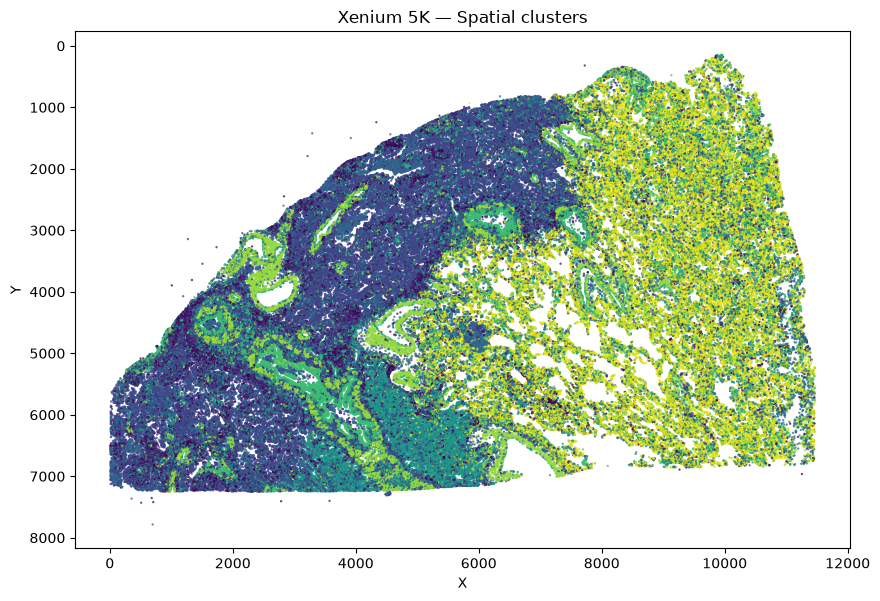

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

scatter = ax.scatter(
    cells["x"],
    cells["y"],
    c=cells["group"],
    s=0.5,
    alpha=0.7
)

ax.set_aspect("equal")
#ax.invert_xaxis()
ax.invert_yaxis()
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Xenium 5K — Spatial clusters")

plt.show()